# Qwen2.5-Coder-1.5B

In [1]:
!pip install transformers datasets peft accelerate scikit-learn \
             matplotlib seaborn bitsandbytes -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.9 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'


In [3]:
import torch
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU            :', torch.cuda.get_device_name(0))
    print('VRAM (GB)      :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))


CUDA available : True
GPU            : Tesla T4
VRAM (GB)      : 15.6


In [4]:
from kaggle_secrets import UserSecretsClient
secret_label = "HF_TOKEN"
secret_value = UserSecretsClient().get_secret(secret_label)
from huggingface_hub import login
if secret_value:
    login(token=secret_value)
    print('HuggingFace login OK')
else:
    print('WARNING: HF_TOKEN not set')


HuggingFace login OK


In [5]:
import os, warnings, collections, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import torch

from datasets import load_dataset, concatenate_datasets
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, DataCollatorWithPadding,
    EarlyStoppingCallback,
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
)

# ── Chart style ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE = {'blue': '#4C72B0', 'orange': '#DD8452',
            'green': '#55A868', 'red': '#C44E52', 'purple': '#8172B3'}

# ── Hyper-parameters ───────────────────────────────────────────────────────
MODEL_ID    = 'Qwen/Qwen2.5-Coder-0.5B'
HF_TOKEN    = secret_value
MAX_LEN     = 512
TRAIN_SEED  = 42

# FIX 1 – stratified subsample sizes (per class)
SAMPLES_PER_CLASS_TRAIN = 3000   # → 6 000 total, balanced 50/50
SAMPLES_PER_CLASS_VALID = 600    # → 1 200 total

BATCH_SIZE  = 8
GRAD_ACC    = 4               # effective batch = 32
# FIX 2 – lower, stable LR for LoRA
LR          = 2e-5
EPOCHS      = 5

# FIX 3 – leaner LoRA (less over-fitting, faster convergence)
LORA_R      = 16
LORA_ALPHA  = 32
LORA_DROP   = 0.05
LORA_TARGETS = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
LABEL_SMOOTH = 0.1             # FIX 4 – label smoothing
NUM_LABELS  = 2
OUTPUT_DIR  = './results-qwen2.5-coder-0.5b-improved'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Model  : {MODEL_ID}')


Device : cuda
Model  : Qwen/Qwen2.5-Coder-0.5B


In [6]:
# ── FIX 1: Stratified balanced sampling ──────────────────────────────────
# Thay vì random.select() gây mất cân bằng,
# ta tách theo nhãn rồi lấy đủ mỗi class.

dataset = load_dataset('google/code_x_glue_cc_defect_detection')

def stratified_subsample(split, n_per_class, seed=42):
    """Lấy n_per_class mẫu cho mỗi nhãn (0 và 1)."""
    class0 = split.filter(lambda x: x['target'] == 0).shuffle(seed=seed)
    class1 = split.filter(lambda x: x['target'] == 1).shuffle(seed=seed)
    n0 = min(n_per_class, len(class0))
    n1 = min(n_per_class, len(class1))
    balanced = concatenate_datasets([
        class0.select(range(n0)),
        class1.select(range(n1)),
    ]).shuffle(seed=seed)
    return balanced

train_sub = stratified_subsample(dataset['train'], SAMPLES_PER_CLASS_TRAIN, TRAIN_SEED)
valid_sub = stratified_subsample(dataset['validation'], SAMPLES_PER_CLASS_VALID, TRAIN_SEED)
test_split = dataset['test']

print(f'Train subset : {len(train_sub):,}  |  label dist: {collections.Counter(train_sub["target"])}')
print(f'Valid subset : {len(valid_sub):,}  |  label dist: {collections.Counter(valid_sub["target"])}')
print(f'Test split   : {len(test_split):,}  |  label dist: {collections.Counter(test_split["target"])}')


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/2.21M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/2.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/21854 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/21854 [00:00<?, ? examples/s]

Filter:   0%|          | 0/21854 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2732 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2732 [00:00<?, ? examples/s]

Train subset : 6,000  |  label dist: Counter({True: 3000, False: 3000})
Valid subset : 1,200  |  label dist: Counter({False: 600, True: 600})
Test split   : 2,732  |  label dist: Counter({False: 1477, True: 1255})


In [7]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID, token=HF_TOKEN, trust_remote_code=True,
)
if tokenizer.pad_token is None:
    tokenizer.pad_token     = tokenizer.eos_token
    tokenizer.pad_token_id  = tokenizer.eos_token_id
tokenizer.padding_side = 'left'   # required for decoder-only classifiers
ORIGINAL_BOS_ID = tokenizer.bos_token_id
print('Vocab size   :', tokenizer.vocab_size)
print('Pad token    :', tokenizer.pad_token)
print('Padding side :', tokenizer.padding_side)


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size   : 151643
Pad token    : <|endoftext|>
Padding side : left


In [8]:
# ── FIX 5: Tokenize only the code (no double-encoding as text pair) ──────
# Bug cũ: truyền (prompt, func) như text-pair gây segment-embedding lệch.
# Fix: encode prompt + code nối nhau thành một chuỗi duy nhất.

from datasets import Value

PREFIX = '''You are a code analysis model.\n
Determine whether the following C code contains a defect.\n
Answer with ONLY one word: YES or NO.
Code:\n'''

def tokenize(batch):
    texts = [PREFIX + func for func in batch['func']]
    return tokenizer(
        texts,
        truncation=True,
        max_length=MAX_LEN,
        padding=False,
    )

remove_cols = ['func', 'project', 'commit_id']
train_tok = train_sub.map(tokenize, batched=True, remove_columns=remove_cols)
valid_tok = valid_sub.map(tokenize, batched=True, remove_columns=remove_cols)
test_tok  = test_split.map(tokenize, batched=True, remove_columns=remove_cols)

# Rename 'target' -> 'labels' and force int64 for CE loss compatibility
train_tok = train_tok.rename_column('target', 'labels').cast_column('labels', Value('int64'))
valid_tok = valid_tok.rename_column('target', 'labels').cast_column('labels', Value('int64'))
test_tok  = test_tok.rename_column('target', 'labels').cast_column('labels', Value('int64'))

train_tok.set_format('torch')
valid_tok.set_format('torch')
test_tok.set_format('torch')

print('Tokenization complete.  Train features:', train_tok.features)
print('Label tensor dtype:', train_tok[0]['labels'].dtype)


Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2732 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/6000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1200 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2732 [00:00<?, ? examples/s]

Tokenization complete.  Train features: {'id': Value('int32'), 'labels': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}
Label tensor dtype: torch.int64


In [9]:
# ── FIX 6: fp16 consistency – load AND train both in bf16 (or both fp32) ──
USE_BF16 = torch.cuda.is_bf16_supported()
USE_FP16 = False
DTYPE    = torch.bfloat16 if USE_BF16 else torch.float32
print(f'Training dtype : {DTYPE}')


# device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else ""
# USE_BF16 = False       
# USE_FP16 = torch.cuda.is_available()
# DTYPE    = torch.float16 if USE_FP16 else torch.float32
# print(f'Training dtype : {DTYPE}  (GPU: {device_name})')

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    num_labels=NUM_LABELS,
    token=HF_TOKEN,
    trust_remote_code=True,
    torch_dtype=DTYPE,
    device_map='auto' if DEVICE == 'cuda' else None,
    ignore_mismatched_sizes=True,
)
model.config.pad_token_id  = tokenizer.pad_token_id
if model.config.bos_token_id is None:
    model.config.bos_token_id = ORIGINAL_BOS_ID
model.config.problem_type  = 'single_label_classification'

with torch.no_grad():
    model.score.weight.data *= 0.01

# ── FIX 3: lean LoRA – only attention layers, NOT MLP projections ─────────
lora_config = LoraConfig(
    task_type    = TaskType.SEQ_CLS,
    r            = LORA_R,
    lora_alpha   = LORA_ALPHA,
    lora_dropout = LORA_DROP,
    bias         = 'none',
    target_modules   = LORA_TARGETS,  # only Q & V → stable + fast
    modules_to_save  = ['score'],
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


Training dtype : torch.bfloat16


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen2.5-Coder-0.5B
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 2,164,480 || all params: 496,199,040 || trainable%: 0.4362


In [10]:
from scipy.special import softmax
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def build_compute_metrics(threshold=0.4):
    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = softmax(logits, axis=-1)[:, 1]
        preds = (probs > threshold).astype(int)

        return {
            'accuracy' : accuracy_score(labels, preds),
            'precision': precision_score(labels, preds, zero_division=0),
            'recall'   : recall_score(labels, preds, zero_division=0),
            'f1'       : f1_score(labels, preds, zero_division=0),
        }
    return compute_metrics

compute_metrics = build_compute_metrics(0.4)

In [11]:
from torch.nn import CrossEntropyLoss

# ── FIX 2: stable TrainingArguments ────────────────────────────────────────
steps_per_epoch = len(train_tok) // (BATCH_SIZE * GRAD_ACC)
# warmup_steps    = max(50, steps_per_epoch * 2)   # 2 epochs warm-up
warmup_steps    = 50  

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = 4,
    gradient_accumulation_steps = GRAD_ACC,
    learning_rate               = LR,
    weight_decay                = 0.01,
    warmup_steps                = warmup_steps,
    lr_scheduler_type           = 'cosine',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    # FIX 6: consistent dtype
    # bf16                        = USE_BF16,
    # fp16                        = False,
    fp16                        = USE_FP16,
    bf16                        = USE_BF16,
    max_grad_norm               = 0.3,
    logging_steps               = 10,
    report_to                   = 'none',
    dataloader_num_workers      = 2,
    seed                        = TRAIN_SEED,
    gradient_checkpointing      = True,
)
print(f'Warmup steps   : {warmup_steps}')
print(f'Steps/epoch    : {steps_per_epoch}')

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Class weights (still useful even with balanced data; test set is unbalanced)
label_counts  = np.bincount(np.array(train_tok['labels']))
total         = label_counts.sum()
class_weights = torch.tensor(
    [total / (2 * c) for c in label_counts], dtype=torch.float32
).to(DEVICE)
print(f'Class weights  : clean={class_weights[0]:.3f}, defective={class_weights[1]:.3f}')

# ── FIX 4: Label smoothing in custom loss ─────────────────────────────────
class WeightedSmoothTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits.float()
        loss    = CrossEntropyLoss(
            weight        = class_weights,
            label_smoothing = LABEL_SMOOTH,
        )(logits, labels)
        return (loss, outputs) if return_outputs else loss

trainer = WeightedSmoothTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_tok,
    eval_dataset     = valid_tok,
    processing_class = tokenizer,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    # FIX 7: patience=3 – cho model thêm thời gian hội tụ
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=3)],
)
print('Trainer initialized.')


Warmup steps   : 50
Steps/epoch    : 187
Class weights  : clean=1.000, defective=1.000
Trainer initialized.


In [12]:
train_result = trainer.train()
print('Training complete.')
print(f'Training loss    : {train_result.training_loss:.4f}')
print(f'Training runtime : {train_result.metrics["train_runtime"]:.1f}s')


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.650630,0.676293,0.567500,0.587097,0.455000,0.512676
2,2.656637,0.654929,0.530833,0.517051,0.935000,0.665875
3,2.531824,0.651331,0.577500,0.551381,0.831667,0.663123
4,2.515937,0.649536,0.563333,0.537402,0.910000,0.675743
5,2.376168,0.649067,0.568333,0.544086,0.843333,0.661438


Training complete.
Training loss    : 2.5644
Training runtime : 17520.3s


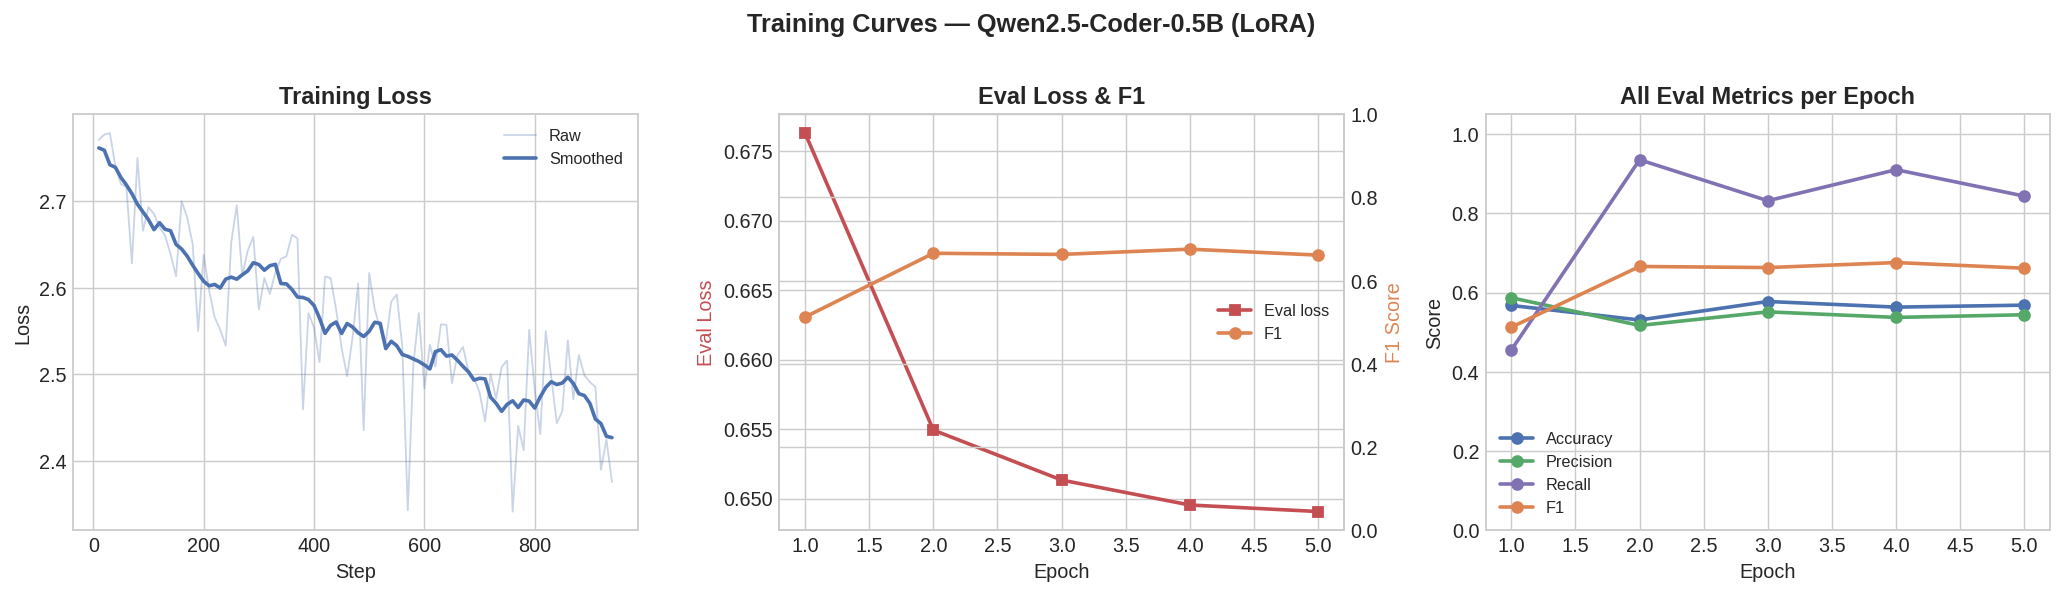

In [13]:
# ── Improved training curves ───────────────────────────────────────────────
from scipy.ndimage import uniform_filter1d   # smoothing for noisy loss curve

log_history = trainer.state.log_history
train_logs  = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs   = [x for x in log_history if 'eval_loss' in x]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- Panel 1: Training loss (raw + smoothed) ---
if train_logs:
    steps  = np.array([x['step'] for x in train_logs])
    losses = np.array([x['loss'] for x in train_logs])
    smooth = uniform_filter1d(losses, size=max(1, len(losses)//10))
    axes[0].plot(steps, losses, alpha=0.3, linewidth=1, color=PALETTE['blue'], label='Raw')
    axes[0].plot(steps, smooth,  linewidth=2,  color=PALETTE['blue'], label='Smoothed')
    axes[0].set_xlabel('Step'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss', fontweight='bold')
    axes[0].legend(fontsize=9)

# --- Panel 2: Eval loss vs F1 (dual-axis) ---
if eval_logs:
    epochs_e = [x['epoch'] for x in eval_logs]
    f1s      = [x.get('eval_f1',  0) for x in eval_logs]
    e_losses = [x.get('eval_loss',0) for x in eval_logs]
    ax2 = axes[1]
    ax2b= ax2.twinx()
    ax2.plot(epochs_e, e_losses, marker='s', color=PALETTE['red'],    linewidth=2, label='Eval loss')
    ax2b.plot(epochs_e, f1s,    marker='o', color=PALETTE['orange'],  linewidth=2, label='F1')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Eval Loss', color=PALETTE['red'])
    ax2b.set_ylabel('F1 Score',            color=PALETTE['orange'])
    ax2b.set_ylim(0, 1)
    axes[1].set_title('Eval Loss & F1', fontweight='bold')
    lines1, l1 = ax2.get_legend_handles_labels()
    lines2, l2 = ax2b.get_legend_handles_labels()
    ax2.legend(lines1+lines2, l1+l2, fontsize=9, loc='center right')

# --- Panel 3: All eval metrics ---
if eval_logs:
    for key, color in [('eval_accuracy', PALETTE['blue']),
                       ('eval_precision', PALETTE['green']),
                       ('eval_recall',   PALETTE['purple']),
                       ('eval_f1',       PALETTE['orange'])]:
        vals = [x.get(key, None) for x in eval_logs]
        if any(v is not None for v in vals):
            axes[2].plot(epochs_e, vals, marker='o', linewidth=2,
                         color=color, label=key.replace('eval_','').capitalize())
    axes[2].set_ylim(0, 1.05)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
    axes[2].set_title('All Eval Metrics per Epoch', fontweight='bold')
    axes[2].legend(fontsize=9)

plt.suptitle('Training Curves — Qwen2.5-Coder-0.5B (LoRA)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight', dpi=150)
plt.show()


In [14]:
# ── Optimal threshold via Youden's J ──────────────────────────────────────
test_output = trainer.predict(test_tok)
logits       = test_output.predictions
labels_test  = test_output.label_ids
probs        = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()[:, 1]

fpr, tpr, thresholds = roc_curve(labels_test, probs)
roc_auc = auc(fpr, tpr)

# Youden's J: maximise sensitivity + specificity simultaneously
J = tpr - fpr
best_thresh = float(thresholds[np.argmax(J)])
print(f'Optimal threshold (Youden J): {best_thresh:.3f}')

preds = (probs > best_thresh).astype(int)
acc = accuracy_score(labels_test, preds)
pre = precision_score(labels_test, preds, zero_division=0)
rec = recall_score(labels_test, preds, zero_division=0)
f1  = f1_score(labels_test, preds, zero_division=0)

print(f'\n=== Test Set Evaluation (threshold={best_thresh:.3f}) ===')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {pre:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1 Score  : {f1:.4f}')
print(f'AUC-ROC   : {roc_auc:.4f}')
print()
print(classification_report(labels_test, preds, target_names=['Clean','Defective']))


Optimal threshold (Youden J): 0.557

=== Test Set Evaluation (threshold=0.557) ===
Accuracy  : 0.6051
Precision : 0.6078
Recall    : 0.3952
F1 Score  : 0.4790
AUC-ROC   : 0.6396

              precision    recall  f1-score   support

       Clean       0.60      0.78      0.68      1477
   Defective       0.61      0.40      0.48      1255

    accuracy                           0.61      2732
   macro avg       0.61      0.59      0.58      2732
weighted avg       0.61      0.61      0.59      2732



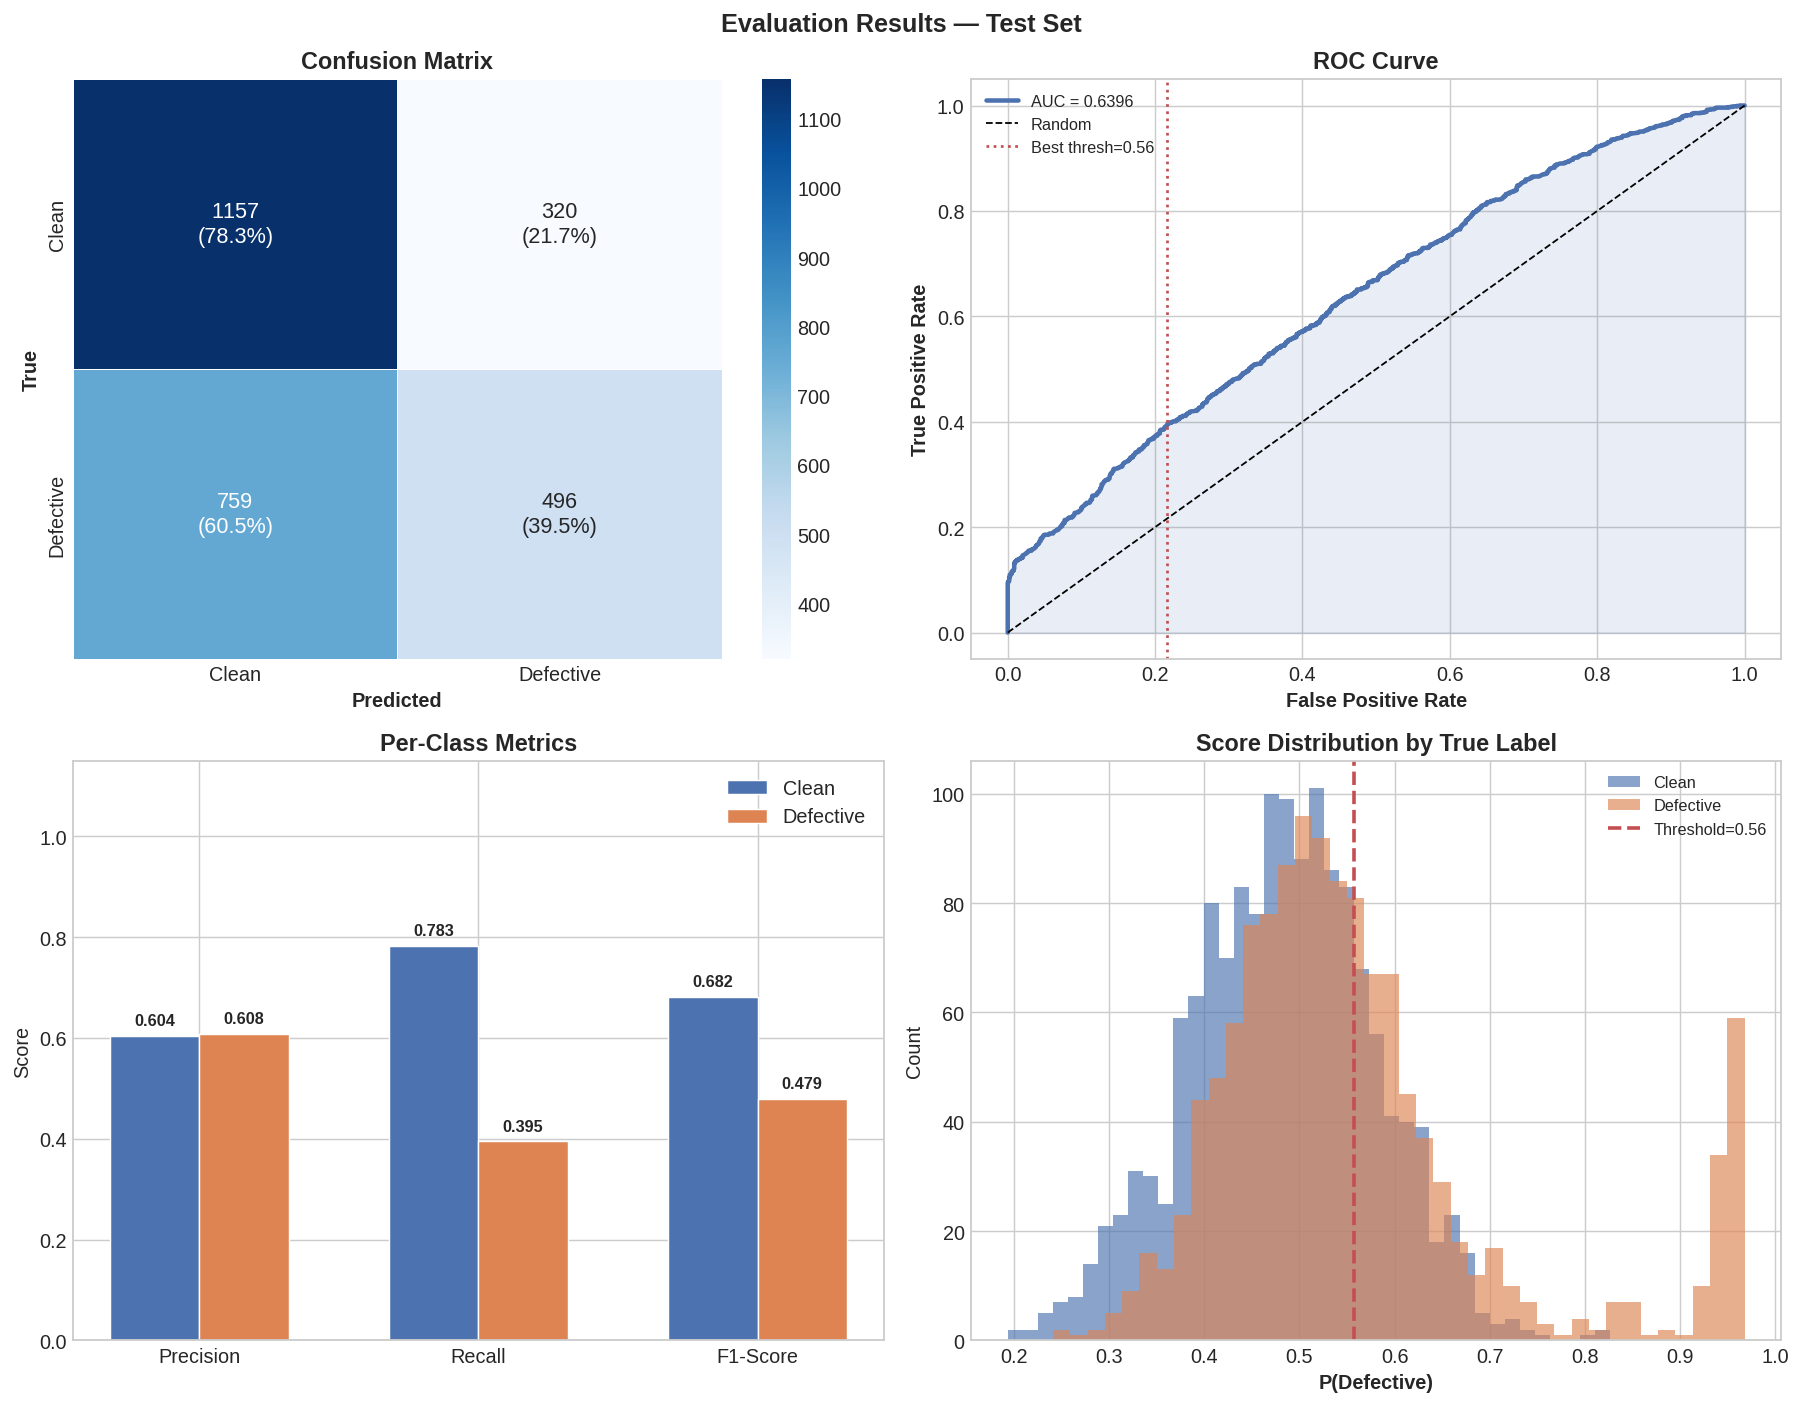

In [15]:
# ── Evaluation visualizations (4-panel) ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Confusion Matrix
cm = confusion_matrix(labels_test, preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = np.array([[f'{v}\n({cm_pct[i,j]:.1f}%)' for j,v in enumerate(row)]
                    for i,row in enumerate(cm)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=['Clean','Defective'],
            yticklabels=['Clean','Defective'],
            ax=axes[0,0], linewidths=0.5, annot_kws={'size':12})
axes[0,0].set_xlabel('Predicted', fontweight='bold')
axes[0,0].set_ylabel('True',      fontweight='bold')
axes[0,0].set_title('Confusion Matrix', fontweight='bold')

# 2. ROC Curve
axes[0,1].plot(fpr, tpr, color=PALETTE['blue'], linewidth=2.5,
               label=f'AUC = {roc_auc:.4f}')
axes[0,1].plot([0,1],[0,1],'k--',linewidth=1,label='Random')
axes[0,1].fill_between(fpr, tpr, alpha=0.12, color=PALETTE['blue'])
axes[0,1].axvline(fpr[np.argmax(J)], color=PALETTE['red'], linestyle=':',
                  linewidth=1.5, label=f'Best thresh={best_thresh:.2f}')
axes[0,1].set_xlabel('False Positive Rate', fontweight='bold')
axes[0,1].set_ylabel('True Positive Rate',  fontweight='bold')
axes[0,1].set_title('ROC Curve', fontweight='bold')
axes[0,1].legend(fontsize=9)

# 3. Per-class metrics bar
class_report = classification_report(
    labels_test, preds, target_names=['Clean','Defective'], output_dict=True
)
metrics_list = ['precision','recall','f1-score']
x = np.arange(len(metrics_list)); width = 0.32
bars1 = axes[1,0].bar(x-width/2, [class_report['Clean'][m]     for m in metrics_list],
                       width, label='Clean',     color=PALETTE['blue'],   edgecolor='white', linewidth=0.8)
bars2 = axes[1,0].bar(x+width/2, [class_report['Defective'][m] for m in metrics_list],
                       width, label='Defective', color=PALETTE['orange'], edgecolor='white', linewidth=0.8)
for bar in list(bars1)+list(bars2):
    h = bar.get_height()
    axes[1,0].text(bar.get_x()+bar.get_width()/2, h+0.015, f'{h:.3f}',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(['Precision','Recall','F1-Score'])
axes[1,0].set_ylim(0, 1.15)
axes[1,0].set_ylabel('Score')
axes[1,0].set_title('Per-Class Metrics', fontweight='bold')
axes[1,0].legend()

# 4. Prediction score distribution
for label_val, color, name in zip([0,1], [PALETTE['blue'],PALETTE['orange']], ['Clean','Defective']):
    subset = probs[labels_test == label_val]
    axes[1,1].hist(subset, bins=40, alpha=0.65, color=color, label=name, edgecolor='none')
axes[1,1].axvline(best_thresh, color=PALETTE['red'], linestyle='--',
                  linewidth=2, label=f'Threshold={best_thresh:.2f}')
axes[1,1].set_xlabel('P(Defective)', fontweight='bold')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Score Distribution by True Label', fontweight='bold')
axes[1,1].legend(fontsize=9)

plt.suptitle('Evaluation Results — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_results.png', bbox_inches='tight', dpi=150)
plt.show()


In [16]:
# Final results summary
results_df = pd.DataFrame([{
    'Model':     MODEL_ID,
    'Accuracy':  round(acc, 4),
    'Precision': round(pre, 4),
    'Recall':    round(rec, 4),
    'F1':        round(f1,  4),
    'AUC':       round(roc_auc, 4),
    'Threshold': round(best_thresh, 3),
}])
print('=== Final Results Summary ===')
print(results_df.to_string(index=False))


=== Final Results Summary ===
                  Model  Accuracy  Precision  Recall    F1    AUC  Threshold
Qwen/Qwen2.5-Coder-0.5B    0.6051     0.6078  0.3952 0.479 0.6396      0.557


In [17]:
model.save_pretrained(OUTPUT_DIR + '/best_model')
tokenizer.save_pretrained(OUTPUT_DIR + '/best_model')
print(f'Model saved to: {OUTPUT_DIR}/best_model')


Model saved to: ./results-qwen2.5-coder-0.5b-improved/best_model
